In [1]:
import importlib
from IPython.display import display

try:
    import helpers.preprocess as prep
    import helpers.solver as solv
    import helpers.output_writer as ow

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ow)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
except ImportError:
    import preprocess as prep
    import solver as solv
    import output_writer as ow

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ow)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs

model_path = "inputs/validation/Validation files from previous examples/verification_moment_release_frame.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print(f"Outputs saved to {output_dir}")
print()

display(tables["model_summary"])
display(tables["node_displacements"])
display(tables["support_reactions"])
display(tables["element_local_end_forces"])
display(tables["element_derived_results"])

Outputs saved to outputs\runs\verification_moment_release_frame



,model_name,length_unit,force_unit,n_nodes,n_elements,n_truss_elements,n_frame_elements,n_free_dofs,n_restrained_dofs,max_displacement_node,max_displacement_magnitude
0,verification_moment_release_frame,m,kN,3,2,0,2,3,15,2,0.000856


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
0,1,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,2,0.0,10.0,0.0,-0.000759,0.000396,0.0,0.0,0.0,0.000000,0.000856,0.000000
2,3,8.0,10.0,0.0,0.000000,0.000000,0.0,0.0,0.0,-0.067617,0.000000,0.067617


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.0,0.0,0.0,150.010115,-37.5,0.0,0.0,0.0,-300.101153,154.626274,300.101153
1,2,0.0,10.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,3,8.0,10.0,0.0,89.989885,-37.5,0.0,0.0,0.0,0.000000,97.490663,0.000000


,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,3D_frame,1,2,-37.500000,-150.010115,0.0,0.0,0.0,-300.101153,37.500000,-89.989885,0.0,0.0,0.0,0.0
1,2,3D_frame,2,3,-89.989885,-37.500000,0.0,0.0,0.0,0.000000,89.989885,-37.500000,0.0,0.0,0.0,0.0


,elem_id,type,node_i,node_j,L,axial_i_local,axial_j_local,axial_abs_max,shear_y_abs_max,shear_z_abs_max,torsion_abs_max,moment_y_abs_max,moment_z_abs_max,moment_abs_max,stress_axial_i,stress_axial_j,stress_axial_abs_max
0,1,3D_frame,1,2,10.0,-37.500000,37.500000,37.500000,150.010115,0.0,0.0,0.0,300.101153,300.101153,-7911.392405,7911.392405,7911.392405
1,2,3D_frame,2,3,8.0,-89.989885,89.989885,89.989885,37.500000,0.0,0.0,0.0,0.000000,0.000000,-18985.207739,18985.207739,18985.207739


In [2]:
import pandas as pd

df_nodes = tables["node_displacements"].copy()

df_disp_key = df_nodes[df_nodes["node_id"].isin([2, 3])][
    ["node_id", "ux", "uy", "rz", "disp_mag", "rot_mag"]
].sort_values("node_id").reset_index(drop=True)

display(df_disp_key)

,node_id,ux,uy,rz,disp_mag,rot_mag
0,2,-0.000759,0.000396,0.000000,0.000856,0.000000
1,3,0.000000,0.000000,-0.067617,0.000000,0.067617


In [3]:
df_react = tables["support_reactions"].copy()

df_react_key = df_react[df_react["node_id"].isin([1, 3])][
    ["node_id", "Rx", "Ry", "Rz", "Mx", "My", "Mz"]
].sort_values("node_id").reset_index(drop=True)

display(df_react_key)

,node_id,Rx,Ry,Rz,Mx,My,Mz
0,1,150.010115,-37.5,0.0,0.0,0.0,-300.101153
1,3,89.989885,-37.5,0.0,0.0,0.0,0.000000


In [4]:
df_local = tables["element_local_end_forces"].copy()

df_local_key = df_local[df_local["elem_id"].isin([1, 2])][
    [
        "elem_id",
        "Fx_i_local", "Fy_i_local", "Fz_i_local",
        "Mx_i_local", "My_i_local", "Mz_i_local",
        "Fx_j_local", "Fy_j_local", "Fz_j_local",
        "Mx_j_local", "My_j_local", "Mz_j_local"
    ]
].sort_values("elem_id").reset_index(drop=True)

display(df_local_key)

,elem_id,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,-37.500000,-150.010115,0.0,0.0,0.0,-300.101153,37.500000,-89.989885,0.0,0.0,0.0,0.0
1,2,-89.989885,-37.500000,0.0,0.0,0.0,0.000000,89.989885,-37.500000,0.0,0.0,0.0,0.0


In [5]:
benchmark_rows = [
    {"quantity": "Node 1 Rx", "benchmark": 150.010, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Rx"].iloc[0])},
    {"quantity": "Node 1 Ry", "benchmark": -37.500, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Ry"].iloc[0])},
    {"quantity": "Node 1 Mz", "benchmark": -300.101, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Mz"].iloc[0])},

    {"quantity": "Node 3 Rx", "benchmark": 89.990, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Rx"].iloc[0])},
    {"quantity": "Node 3 Ry", "benchmark": -37.500, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Ry"].iloc[0])},

    {"quantity": "Node 2 ux", "benchmark": -0.001, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "ux"].iloc[0])},
    {"quantity": "Node 2 uy", "benchmark":  0.001, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "uy"].iloc[0])},
    {"quantity": "Node 3 rz", "benchmark": -0.068, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 3, "rz"].iloc[0])},
]

df_compare = pd.DataFrame(benchmark_rows)
df_compare["difference"] = df_compare["code"] - df_compare["benchmark"]

def pct_diff(row):
    b = row["benchmark"]
    if abs(b) < 1e-14:
        return None
    return 100.0 * (row["code"] - b) / b

df_compare["percent_difference"] = df_compare.apply(pct_diff, axis=1)

display(df_compare)

,quantity,benchmark,code,difference,percent_difference
0,Node 1 Rx,150.010,150.010115,0.000115,0.000077
1,Node 1 Ry,-37.500,-37.500000,0.000000,-0.000000
2,Node 1 Mz,-300.101,-300.101153,-0.000153,0.000051
3,Node 3 Rx,89.990,89.989885,-0.000115,-0.000128
4,Node 3 Ry,-37.500,-37.500000,0.000000,-0.000000
5,Node 2 ux,-0.001,-0.000759,0.000241,-24.059169
6,Node 2 uy,0.001,0.000396,-0.000604,-60.443038
7,Node 3 rz,-0.068,-0.067617,0.000383,-0.563215


In [6]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)
    from plotting_plotly import plot_structure_plotly

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=35.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=True,
    show_node_labels=True,
    show_element_hover=True,
    show_member_loads=True,
    member_load_scale=0.02,
    title="Moment release verification interactive",
    save_html="outputs/validation/plotly_plots/verification_moment_release_frame.html",
    save_png="outputs/validation/plotly_plots/verification_moment_release_frame.png",
)

fig.show()

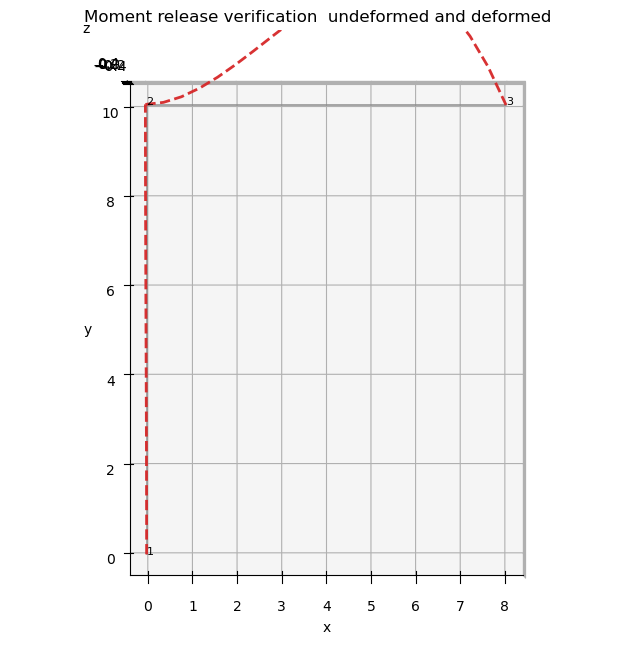

Saved simple plot to outputs\validation\simple_plots\verification_moment_release_frame.png


<Figure size 640x480 with 0 Axes>

In [7]:
import importlib
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import helpers.plotting_simple as ps
    importlib.reload(ps)
    from helpers.plotting_simple import plot_structure_simple
except ImportError:
    import plotting_simple as ps
    importlib.reload(ps)
    from plotting_simple import plot_structure_simple

_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=35.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=True,
    show_element_labels=False,
    title="Moment release verification  undeformed and deformed",
    view="xy",
)

simple_plot_path = Path("outputs/validation/simple_plots/verification_moment_release_frame.png")
simple_plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.gcf().savefig(simple_plot_path, dpi=300, bbox_inches="tight")
print(f"Saved simple plot to {simple_plot_path}")

plt.show()